## MoleculeNet 上的消融实验 (Baseline vs Hybrid GNN)
利用 PyTorch Geometric 的官方 `MoleculeNet` (ESOL) 图数据集：
图结构特征 (`data.x`, `data.edge_index`) 完全使用 PyG 官方数据集中的 9 维标准节点特征。

对于混合模型，我们同时利用 RDKit 在同个分子的 SMILES 上计算你之前筛选出的 Top10 描述符，附加在图数据中进行训练。

在这里我们进行严格并排训练，并在最后用同一张验证集图表对比。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# 1. 加载官方 MoleculeNet 数据集
dataset_mn = MoleculeNet(root='data/MoleculeNet', name='ESOL')

# 2. 提取 SMILES 并计算 Top-10 物理描述符
top_10_descs = ['MolLogP', 'PEOE_VSA6', 'MolMR', 'LabuteASA', 'Chi0v', 'MolWt', 'Chi1v', 'FpDensityMorgan1', 'BCUT2D_LOGPHI', 'BertzCT']
desc_calc = MoleculeDescriptors.MolecularDescriptorCalculator(top_10_descs)

all_descriptors = []
valid_indices = []

for i, data in enumerate(dataset_mn):
    try:
        smiles = data.smiles
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            all_descriptors.append([0.0]*10)
        else:
            desc = desc_calc.CalcDescriptors(mol)
            all_descriptors.append(list(desc))
            valid_indices.append(i)
    except Exception as e:
        all_descriptors.append([0.0]*10)


desc_array = np.array(all_descriptors)
# 处理可能的 NaN 或 Inf
desc_array[np.isnan(desc_array)] = 0.0
desc_array[np.isinf(desc_array)] = 0.0

scaler = MinMaxScaler()
desc_normalized = scaler.fit_transform(desc_array)

# 将归一化后的描述符挂载到数据集的每个对象中
data_list = []
for i, data in enumerate(dataset_mn):
    # 手动转为 Float 格式，并挂载 desc 特征
    data.x = data.x.float()
    data.y = data.y.float()
    data.descriptors = torch.tensor([desc_normalized[i]], dtype=torch.float)
    data_list.append(data)

print(f"数据准备完成。描述符纬度：{data_list[0].descriptors.shape}")

数据准备完成。描述符纬度：torch.Size([1, 10])


In [ ]:
# 3. 严格的数据集划分（在同一个Loader中训练）
train_size = int(len(data_list) * 0.8)
test_size = len(data_list) - train_size
# 固定 Seed，确保两次切分的数据绝对一致
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = torch.utils.data.random_split(data_list, [train_size, test_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 4. 定义模型架构
# --- 模型 A: Baseline GNN (纯 GNN) ---
class BaselineGNN(nn.Module):
    def __init__(self, node_feature_dim=9, gnn_hidden_dim=64):
        super(BaselineGNN, self).__init__()
        self.conv1 = GCNConv(node_feature_dim, gnn_hidden_dim)
        self.bn_gnn1 = nn.BatchNorm1d(gnn_hidden_dim)

        self.conv2 = GCNConv(gnn_hidden_dim, gnn_hidden_dim)
        self.bn_gnn2 = nn.BatchNorm1d(gnn_hidden_dim)

        self.conv3 = GCNConv(gnn_hidden_dim, gnn_hidden_dim)
        self.bn_gnn3 = nn.BatchNorm1d(gnn_hidden_dim)
        
        self.fc1 = nn.Linear(gnn_hidden_dim, 64)
        self.bn_fc1 = nn.BatchNorm1d(64)
        self.out = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        gnn_x = self.conv1(x, edge_index)
        gnn_x = self.bn_gnn1(gnn_x)
        gnn_x = F.relu(gnn_x)
        
        gnn_x = self.conv2(gnn_x, edge_index)
        gnn_x = self.bn_gnn2(gnn_x)
        gnn_x = F.relu(gnn_x)

        gnn_x = self.conv3(gnn_x, edge_index)
        gnn_x = self.bn_gnn3(gnn_x)
        gnn_x = F.relu(gnn_x)
        
        graph_embedding = global_mean_pool(gnn_x, batch)
        
        out = self.fc1(graph_embedding)
        out = self.bn_fc1(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        return self.out(out)

# --- 模型 B: Hybrid GNN (GNN + 描述符) ---
class HybridGNN(nn.Module):
    def __init__(self, node_feature_dim=9, descriptor_dim=10, gnn_hidden_dim=64):
        super(HybridGNN, self).__init__()
        self.conv1 = GCNConv(node_feature_dim, gnn_hidden_dim)
        self.bn_gnn1 = nn.BatchNorm1d(gnn_hidden_dim)

        self.conv2 = GCNConv(gnn_hidden_dim, gnn_hidden_dim)
        self.bn_gnn2 = nn.BatchNorm1d(gnn_hidden_dim)

        self.conv3 = GCNConv(gnn_hidden_dim, gnn_hidden_dim)
        self.bn_gnn3 = nn.BatchNorm1d(gnn_hidden_dim)
        
        # 核心不同：线性层拼接了图特征 和 描述符特征
        combined_dim = gnn_hidden_dim + descriptor_dim
        self.fc1 = nn.Linear(combined_dim, 64)
        self.bn_fc1 = nn.BatchNorm1d(64)
        self.out = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, data):
        x, edge_index, batch, descriptors = data.x, data.edge_index, data.batch, data.descriptors

        gnn_x = self.conv1(x, edge_index)
        gnn_x = self.bn_gnn1(gnn_x)
        gnn_x = F.relu(gnn_x)
        
        gnn_x = self.conv2(gnn_x, edge_index)
        gnn_x = self.bn_gnn2(gnn_x)
        gnn_x = F.relu(gnn_x)

        gnn_x = self.conv3(gnn_x, edge_index)
        gnn_x = self.bn_gnn3(gnn_x)
        gnn_x = F.relu(gnn_x)
        
        graph_embedding = global_mean_pool(gnn_x, batch)
        
        # 特征拼接
        combined = torch.cat([graph_embedding, descriptors.view(graph_embedding.size(0), -1)], dim=1)
        
        out = self.fc1(combined)
        out = self.bn_fc1(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        return self.out(out)

# --- 模型 C: Descriptor MLP (纯描述符) ---
class DescriptorMLP(nn.Module):
    def __init__(self, descriptor_dim=10, hidden_dim=64):
        super(DescriptorMLP, self).__init__()
        self.fc1 = nn.Linear(descriptor_dim, hidden_dim)
        self.bn_fc1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn_fc2 = nn.BatchNorm1d(hidden_dim // 2)
        self.out = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, data):
        descriptors = data.descriptors.view(data.y.size(0), -1)
        
        out = self.fc1(descriptors)
        out = self.bn_fc1(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.bn_fc2(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        return self.out(out)

In [ ]:
# 5. 并排训练与评估
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_baseline = BaselineGNN().to(device)
model_hybrid = HybridGNN().to(device)
model_mlp = DescriptorMLP().to(device)

criterion = nn.MSELoss()
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer_hybrid = torch.optim.Adam(model_hybrid.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)

def train(model, optimizer):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out.view(-1), data.y.view(-1).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out.view(-1), data.y.view(-1).float())
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

EPOCHS = 300
print("开始并排训练三个模型...")

for epoch in range(1, EPOCHS + 1):
    loss_b = train(model_baseline, optimizer_baseline)
    loss_h = train(model_hybrid, optimizer_hybrid)
    loss_m = train(model_mlp, optimizer_mlp)
    
    if epoch % 20 == 0:
        test_b = test(model_baseline, test_loader)
        test_h = test(model_hybrid, test_loader)
        test_m = test(model_mlp, test_loader)
        print(f"E: {epoch:03d} | [GNN] Tr: {loss_b:.4f}, Te: {test_b:.4f} | " 
              f"[MLP] Tr: {loss_m:.4f}, Te: {test_m:.4f} | "
              f"[Hyb] Tr: {loss_h:.4f}, Te: {test_h:.4f}")

Device: cuda
开始并排训练三个模型...
E: 020 | [GNN] Tr: 0.8685, Te: 0.8055 | [MLP] Tr: 0.9425, Te: 0.7184 | [Hyb] Tr: 0.6814, Te: 0.6122
E: 040 | [GNN] Tr: 0.6549, Te: 0.7713 | [MLP] Tr: 0.7432, Te: 0.5872 | [Hyb] Tr: 0.5205, Te: 0.4668
E: 060 | [GNN] Tr: 0.6465, Te: 1.0331 | [MLP] Tr: 0.7417, Te: 0.6134 | [Hyb] Tr: 0.5149, Te: 0.6046
E: 080 | [GNN] Tr: 0.6517, Te: 0.5439 | [MLP] Tr: 0.6620, Te: 0.5183 | [Hyb] Tr: 0.5342, Te: 0.4540
E: 100 | [GNN] Tr: 0.5330, Te: 0.6034 | [MLP] Tr: 0.7203, Te: 0.5180 | [Hyb] Tr: 0.4694, Te: 0.5656
E: 120 | [GNN] Tr: 0.5251, Te: 0.5695 | [MLP] Tr: 0.6850, Te: 0.5101 | [Hyb] Tr: 0.4083, Te: 0.5950
E: 140 | [GNN] Tr: 0.5800, Te: 0.8628 | [MLP] Tr: 0.6104, Te: 0.5301 | [Hyb] Tr: 0.4678, Te: 0.4618
E: 160 | [GNN] Tr: 0.4606, Te: 0.5834 | [MLP] Tr: 0.5937, Te: 0.4965 | [Hyb] Tr: 0.3867, Te: 0.4963
E: 180 | [GNN] Tr: 0.5414, Te: 0.7373 | [MLP] Tr: 0.5550, Te: 0.4773 | [Hyb] Tr: 0.4413, Te: 0.5524
E: 200 | [GNN] Tr: 0.4189, Te: 0.5531 | [MLP] Tr: 0.6165, Te: 0.4982 | [H

最终结果 (在 MoleculeNet ESOL 测试集上):
[纯GNN Baseline] RMSE: 0.7433, MAE: 0.5670
[纯描述符 MLP]   RMSE: 0.6987, MAE: 0.5384
[混合特征 Hybrid] RMSE: 0.6718, MAE: 0.4965


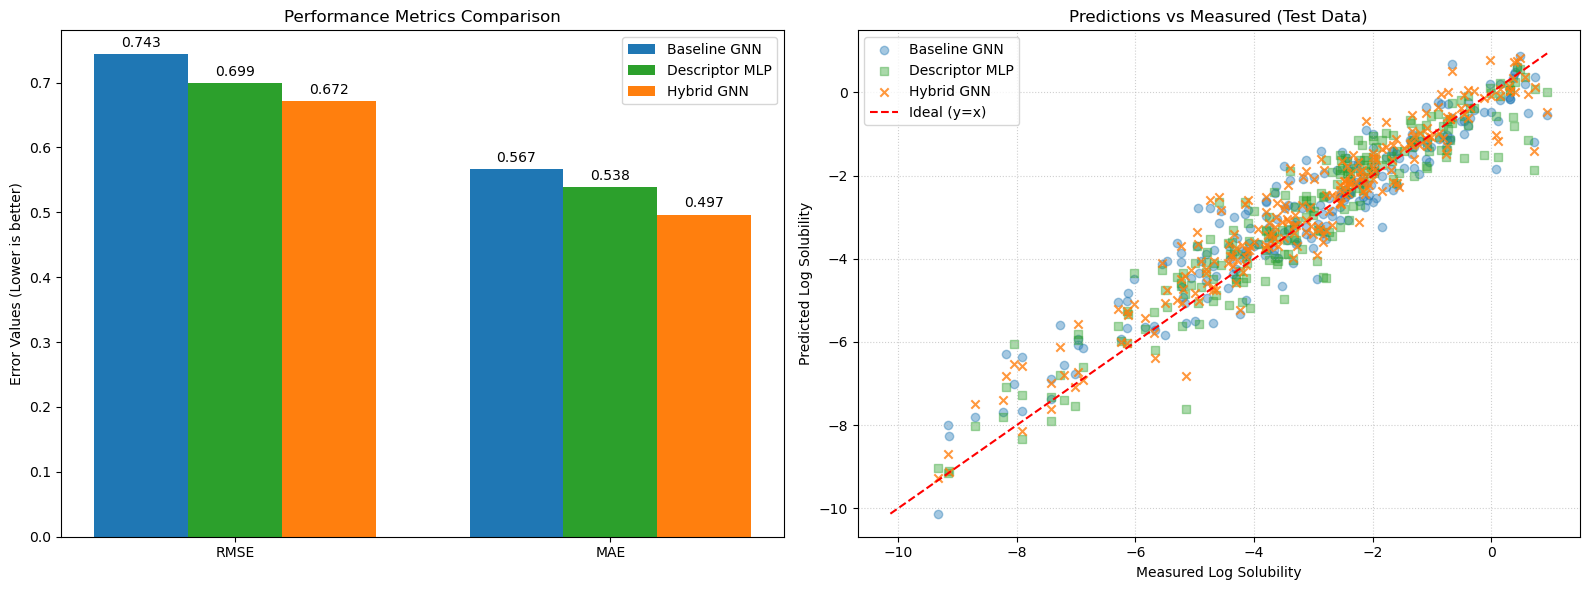

In [ ]:
# 6. 计算最终测试集的 RMSE 和 MAE，并绘图直观对比
model_baseline.eval()
model_hybrid.eval()
model_mlp.eval()

preds_baseline = []
preds_hybrid = []
preds_mlp = []
targets = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        targets.append(data.y.view(-1).float().cpu())
        
        preds_baseline.append(model_baseline(data).view(-1).cpu())
        preds_hybrid.append(model_hybrid(data).view(-1).cpu())
        preds_mlp.append(model_mlp(data).view(-1).cpu())

targets = torch.cat(targets).numpy()
preds_baseline = torch.cat(preds_baseline).numpy()
preds_hybrid = torch.cat(preds_hybrid).numpy()
preds_mlp = torch.cat(preds_mlp).numpy()

# 计算指标
rmse_b = np.sqrt(np.mean((preds_baseline - targets)**2))
mae_b = np.mean(np.abs(preds_baseline - targets))

rmse_m = np.sqrt(np.mean((preds_mlp - targets)**2))
mae_m = np.mean(np.abs(preds_mlp - targets))

rmse_h = np.sqrt(np.mean((preds_hybrid - targets)**2))
mae_h = np.mean(np.abs(preds_hybrid - targets))

print("="*50)
print(f"最终结果 (在 MoleculeNet ESOL 测试集上):")
print(f"[纯GNN Baseline] RMSE: {rmse_b:.4f}, MAE: {mae_b:.4f}")
print(f"[纯描述符 MLP]   RMSE: {rmse_m:.4f}, MAE: {mae_m:.4f}")
print(f"[混合特征 Hybrid] RMSE: {rmse_h:.4f}, MAE: {mae_h:.4f}")
print("="*50)

# 使用柱状图与散点图综合对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 图1: RMSE & MAE 柱状图对比
b_scores = [rmse_b, mae_b]
m_scores = [rmse_m, mae_m]
h_scores = [rmse_h, mae_h]
x = np.arange(2)
width = 0.25

rects1 = ax1.bar(x - width, b_scores, width, label='Baseline GNN', color='#1f77b4')
rects2 = ax1.bar(x, m_scores, width, label='Descriptor MLP', color='#2ca02c')
rects3 = ax1.bar(x + width, h_scores, width, label='Hybrid GNN', color='#ff7f0e')

ax1.set_ylabel('Error Values (Lower is better)')
ax1.set_title('Performance Metrics Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(['RMSE', 'MAE'])
ax1.legend()
ax1.bar_label(rects1, padding=3, fmt='%.3f')
ax1.bar_label(rects2, padding=3, fmt='%.3f')
ax1.bar_label(rects3, padding=3, fmt='%.3f')

# 图2: 散点预测图对比
ax2.scatter(targets, preds_baseline, alpha=0.4, color='#1f77b4', marker='o', label=f'Baseline GNN')
ax2.scatter(targets, preds_mlp, alpha=0.4, color='#2ca02c', marker='s', label=f'Descriptor MLP')
ax2.scatter(targets, preds_hybrid, alpha=0.8, color='#ff7f0e', marker='x', label=f'Hybrid GNN')

min_v = min(targets.min(), preds_baseline.min(), preds_mlp.min(), preds_hybrid.min())
max_v = max(targets.max(), preds_baseline.max(), preds_mlp.max(), preds_hybrid.max())
ax2.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', label='Ideal (y=x)')

ax2.set_xlabel('Measured Log Solubility')
ax2.set_ylabel('Predicted Log Solubility')
ax2.set_title('Predictions vs Measured (Test Data)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()